## RNA semantic encoder

This notebook tests the RNA encoder only. It reads the RNA modality from the mouse `h5mu`, trains an RNA-only autoencoder with the same encoder architecture used in `Squidiff/MLPModel.py`, and then visualizes the learned latent with PCA and UMAP.

In [9]:
import os
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    import muon as mu
except ImportError:
    import mudata as mu


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "Squidiff").exists() and (cwd / "data").exists():
        return cwd
    if cwd.name == "scripts" and (cwd.parent / "Squidiff").exists():
        return cwd.parent
    return cwd


def to_dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


def inspect_adata(adata, label: str, group_key: str | None = None):
    print(f"=== {label} ===")
    print(adata)
    print("X type:", type(adata.X))
    print("obs columns:", list(adata.obs.columns))
    print("var_names head:", adata.var_names[:10].tolist())

    if group_key is not None and group_key in adata.obs.columns:
        print(f"{group_key} distribution:")
        print(adata.obs[group_key].value_counts(dropna=False).sort_index())

    x = to_dense_float32(adata.X)
    summary = pd.Series(
        {
            "n_obs": int(adata.n_obs),
            "n_vars": int(adata.n_vars),
            "min": float(x.min()),
            "max": float(x.max()),
            "mean": float(x.mean()),
            "std": float(x.std()),
            "zero_fraction": float((x == 0).mean()),
        },
        name=label,
    )
    display(summary.to_frame())

    plt.figure(figsize=(6, 4))
    plt.hist(x.ravel(), bins=100, color="#4C78A8", alpha=0.85)
    plt.title(f"{label}: expression distribution")
    plt.xlabel("Expression value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return summary


def first_existing_key(obs_df: pd.DataFrame, candidates):
    for key in candidates:
        if key in obs_df.columns:
            return key
    return None


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_ROOT = resolve_repo_root()
print("device:", device)
print("REPO_ROOT:", REPO_ROOT)

device: cuda
REPO_ROOT: /home/anniehuang/Squidiff


### Read file

The source file is multi-omics, but everything below is restricted to the RNA modality only.

Mouse file exists: True
Mouse path: /home/anniehuang/Squidiff/data/mouse/processed/mouse_train.h5mu
MuData object with n_obs × n_vars = 9358 × 69575
  var:	'interval'
  uns:	'stage_to_group'
  2 modalities
    rna:	9358 × 2810
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg'
      layers:	'counts'
    atac:	9358 × 66765
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'interval', 'chrom', 'start', 'end'
      layers:	'counts'
Available modalities: ['rna', 'atac']
=== Mouse RNA train ===
AnnData object with n_obs × n_vars = 9358 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
    var: 'gene

/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


,Mouse RNA train
n_obs,9358.000000
n_vars,2810.000000
min,0.000000
max,8.065309
mean,0.196478
std,0.545761
zero_fraction,0.851320


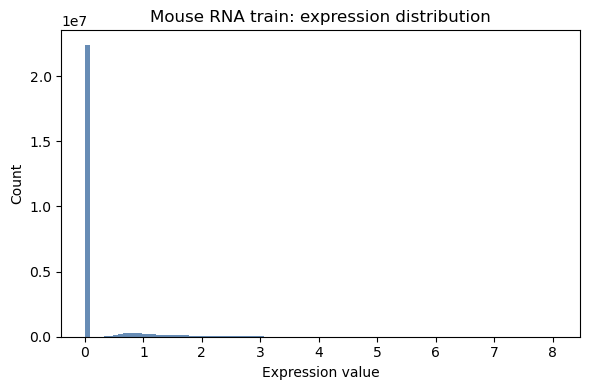

group_key: Group
day_key: stage


In [2]:
mouse_fn = REPO_ROOT / "data" / "mouse" / "processed" / "mouse_train.h5mu"
print("Mouse file exists:", mouse_fn.exists())
print("Mouse path:", mouse_fn)

mouse_mdata = mu.read_h5mu(mouse_fn)
print(mouse_mdata)
print("Available modalities:", list(mouse_mdata.mod.keys()))

mouse_rna = mouse_mdata["rna"].copy()
group_key = first_existing_key(mouse_rna.obs, ["Group", "group", "cell_type", "celltype"])
day_key = first_existing_key(mouse_rna.obs, ["Day", "day", "stage", "time", "batch_stage"])
mouse_summary = inspect_adata(mouse_rna, label="Mouse RNA train", group_key=group_key)
print("group_key:", group_key)
print("day_key:", day_key)

### MLP Encoder

The encoder below is copied from `Squidiff/MLPModel.py -> EncoderMLPModel` and then wrapped in an RNA-only autoencoder so we can train it with reconstruction loss and inspect the latent.

In [3]:
@dataclass
class TrainConfig:
    batch_size: int = 256
    epochs: int = 50
    lr: float = 1e-3
    patience: int = 8
    hidden_size: int = 512
    latent_dim: int = 60
    dropout: float = 0.1
    weight_decay: float = 1e-4
    val_size: float = 0.2
    random_state: int = 42
    chpt_pth: str = str(REPO_ROOT / "checkpoints" / "rna_encoder.pt")


class RNADataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = torch.from_numpy(np.asarray(x, dtype=np.float32))

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], idx


# Copied from Squidiff/MLPModel.py and used here for RNA only.
class EncoderMLPModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes=None, use_drug_structure=False, drug_dimension=1024, comb_num=1, output_size=60, dropout=0.1, use_fp16=False):
        super(EncoderMLPModel, self).__init__()
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.dtype = torch.float16 if use_fp16 else torch.float32
        self.drug_dimension = drug_dimension

        if num_classes is None:
            l1 = 0
        else:
            l1 = hidden_sizes
        if use_drug_structure:
            l2 = drug_dimension
        else:
            l2 = 0

        self.fc1 = nn.Linear(input_size + l1 + l2, hidden_sizes)
        self.bn1 = nn.BatchNorm1d(hidden_sizes)
        self.bn2 = nn.BatchNorm1d(hidden_sizes)
        self.fc2 = nn.Linear(hidden_sizes, hidden_sizes)
        self.fc3 = nn.Linear(hidden_sizes, output_size)
        self.label_embed = nn.Linear(1, hidden_sizes)

    def forward(self, x_start, label=None, drug_dose=None, control_feature=None):
        if label is not None:
            label_emb = self.label_embed(label)
            x_start = torch.concat([x_start, label_emb], axis=1)

        if drug_dose is not None:
            x_start = torch.concat([control_feature, drug_dose], axis=1)

        h = x_start.type(self.dtype)
        h = F.relu(self.bn1(self.fc1(h)))
        h = F.relu(self.bn2(self.fc2(h)))
        h = self.fc3(h)
        return h


class RNAAutoencoder(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 512, latent_dim: int = 60, dropout: float = 0.1):
        super().__init__()
        self.encoder = EncoderMLPModel(
            input_size=input_size,
            hidden_sizes=hidden_size,
            num_classes=None,
            use_drug_structure=False,
            output_size=latent_dim,
            dropout=dropout,
            use_fp16=False,
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat


def make_loaders(x: np.ndarray, config: TrainConfig):
    indices = np.arange(len(x))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=config.val_size,
        random_state=config.random_state,
        shuffle=True,
    )

    train_loader = DataLoader(RNADataset(x[train_idx]), batch_size=config.batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(RNADataset(x[val_idx]), batch_size=config.batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, train_idx, val_idx

### Training

This is RNA-only training. The loss is MSE reconstruction only, there is no ATAC branch, no contrastive/covariance loss, and no wandb logging.

Epoch 001 | train 0.207967 | val 0.163030 | lr 1.00e-03


Epoch 002 | train 0.151396 | val 0.144209 | lr 1.00e-03


Epoch 003 | train 0.141520 | val 0.137259 | lr 1.00e-03


Epoch 004 | train 0.135847 | val 0.133421 | lr 1.00e-03


Epoch 005 | train 0.132969 | val 0.130659 | lr 1.00e-03


...

Epoch 044 | train 0.096892 | val 0.111900 | lr 2.50e-04


Epoch 045 | train 0.096270 | val 0.111968 | lr 2.50e-04


Epoch 046 | train 0.096229 | val 0.111975 | lr 2.50e-04


Epoch 047 | train 0.096318 | val 0.112108 | lr 1.25e-04
Early stopping at epoch 47


,epoch,train_loss,val_loss,lr
42,43,0.097618,0.112535,0.000250
43,44,0.096892,0.111900,0.000250
44,45,0.096270,0.111968,0.000250
45,46,0.096229,0.111975,0.000250
46,47,0.096318,0.112108,0.000125


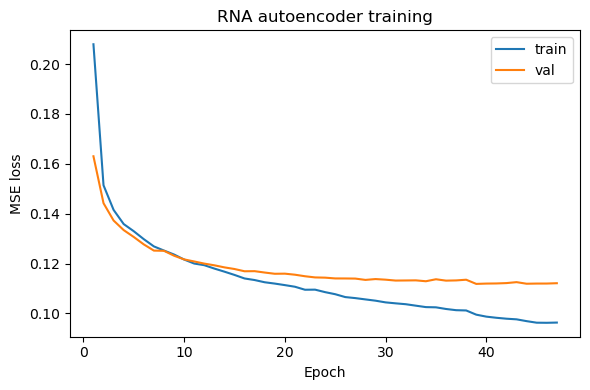

Silhouette score by Group: 0.2081


In [4]:
def training(model, train_loader, val_loader, config: TrainConfig):
    os.makedirs(Path(config.chpt_pth).parent, exist_ok=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(config.epochs):
        model.train()
        train_losses = []
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1:03d} train", leave=False)
        for x_rna, _ in train_bar:
            x_rna = x_rna.to(device)
            _, x_rna_hat = model(x_rna)
            loss = F.mse_loss(x_rna_hat, x_rna)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_losses = []
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch + 1:03d} val", leave=False)
        with torch.no_grad():
            for x_rna, _ in val_bar:
                x_rna = x_rna.to(device)
                _, x_rna_hat = model(x_rna)
                loss = F.mse_loss(x_rna_hat, x_rna)
                val_losses.append(loss.item())
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)

        rec = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(rec)
        print(f"Epoch {epoch + 1:03d} | train {train_loss:.6f} | val {val_loss:.6f} | lr {rec['lr']:.2e}")

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            torch.save(model.state_dict(), config.chpt_pth)
        else:
            wait += 1
            if wait >= config.patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    model.load_state_dict(torch.load(config.chpt_pth, map_location=device))
    return pd.DataFrame(history)


def extract_latent(model, x: np.ndarray, batch_size: int = 1024):
    model.eval()
    loader = DataLoader(RNADataset(x), batch_size=batch_size, shuffle=False)
    latents = []
    with torch.no_grad():
        for x_rna, _ in tqdm(loader, desc="Extract latent", leave=False):
            x_rna = x_rna.to(device)
            z, _ = model(x_rna)
            latents.append(z.cpu().numpy())
    return np.concatenate(latents, axis=0)


config = TrainConfig()
x_rna = to_dense_float32(mouse_rna.X)
train_loader, val_loader, train_idx, val_idx = make_loaders(x_rna, config)

model = RNAAutoencoder(
    input_size=x_rna.shape[1],
    hidden_size=config.hidden_size,
    latent_dim=config.latent_dim,
    dropout=config.dropout,
).to(device)

history_df = training(model, train_loader, val_loader, config)
display(history_df.tail())

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("RNA autoencoder training")
plt.legend()
plt.tight_layout()
plt.show()

z_rna = extract_latent(model, x_rna, batch_size=config.batch_size)
latent_adata = mouse_rna.copy()
latent_adata.obsm["X_rna_encoder"] = z_rna

if group_key is not None and latent_adata.obs[group_key].nunique() > 1:
    sil = silhouette_score(z_rna, latent_adata.obs[group_key].astype(str))
    print(f"Silhouette score by {group_key}: {sil:.4f}")

### Plot

First project the RNA latent with PCA. Then build a neighborhood graph on the same latent, run Leiden + UMAP, and color by Leiden together with the best available day-like metadata column.

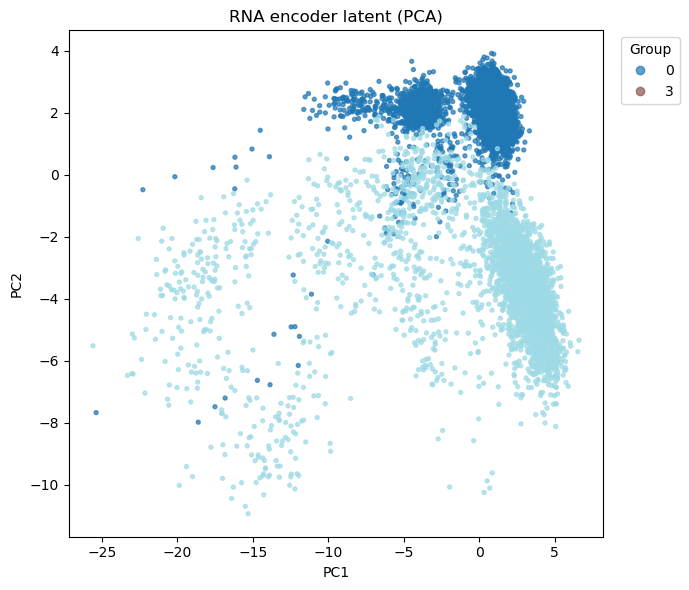

In [5]:
pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(z_rna)

latent_adata.obsm["X_pca_encoder"] = z_pca
plot_group_key = group_key if group_key is not None else day_key

plt.figure(figsize=(7, 6))
if plot_group_key is None:
    plt.scatter(z_pca[:, 0], z_pca[:, 1], s=8, alpha=0.7)
else:
    labels = latent_adata.obs[plot_group_key].astype(str)
    categories = pd.Categorical(labels)
    scatter = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=categories.codes, s=8, alpha=0.7, cmap="tab20")
    handles, legend_labels = scatter.legend_elements(num=min(len(categories.categories), 12))
    plt.legend(handles, list(categories.categories[: len(handles)]), title=plot_group_key, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.title("RNA encoder latent (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/tmp/ipykernel_7756/2684470836.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(latent_adata, key_added="leiden")


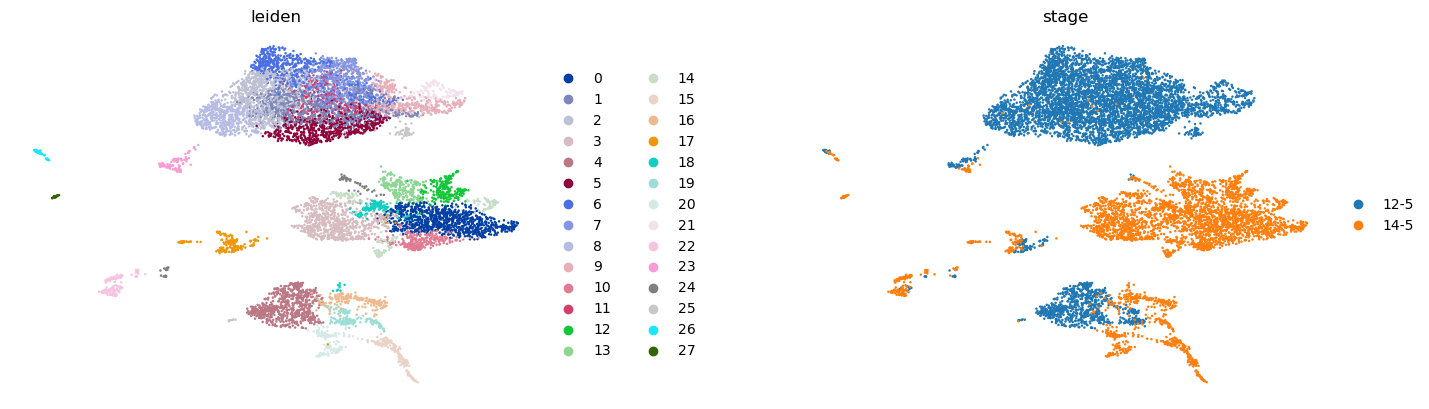

AnnData object with n_obs × n_vars = 9358 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'stage_colors'
    obsm: 'X_rna_encoder', 'X_pca_encoder', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [6]:
sc.pp.neighbors(latent_adata, use_rep="X_rna_encoder", n_neighbors=15)
sc.tl.leiden(latent_adata, key_added="leiden")
sc.tl.umap(latent_adata)

color_keys = ["leiden"]
if day_key is not None:
    color_keys.append(day_key)
else:
    print("No day-like metadata column found; plotting Leiden only.")

sc.pl.umap(latent_adata, color=color_keys, wspace=0.35, frameon=False)
latent_adata

Test file exists: True
Test path: /home/anniehuang/Squidiff/data/mouse/processed/mouse_test.h5mu


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 14672 × 69575
  var:	'interval'
  uns:	'stage_to_group'
  2 modalities
    rna:	14672 × 2810
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt'
      layers:	'counts'
    atac:	14672 × 66765
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'interval', 'chrom', 'start', 'end'
      layers:	'counts'
Available modalities: ['rna', 'atac']
=== Mouse RNA test ===
AnnData object with n_obs × n_vars = 14672 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt'
    layers: 'counts'
X type: <class 'scipy.sparse._csr.csr_matrix'>
obs columns: ['stage', 'replicate', 'Group', 'n_genes_by_c

,Mouse RNA test
n_obs,14672.000000
n_vars,2810.000000
min,0.000000
max,8.432954
mean,0.190502
std,0.524556
zero_fraction,0.846328


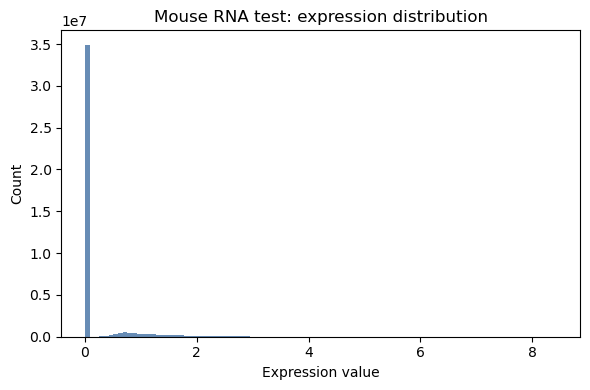

test_group_key: Group
test_day_key: stage
stage
12-5    2910
13-5    5039
14-0    4953
14-5    1770
Name: count, dtype: int64
n_unique_stages: 4


In [7]:
test_fn = REPO_ROOT / "data" / "mouse" / "processed" / "mouse_test.h5mu"
print("Test file exists:", test_fn.exists())
print("Test path:", test_fn)

test_mdata = mu.read_h5mu(test_fn)
print(test_mdata)
print("Available modalities:", list(test_mdata.mod.keys()))

test_rna = test_mdata["rna"].copy()
test_group_key = first_existing_key(test_rna.obs, ["Group", "group", "cell_type", "celltype"])
test_day_key = first_existing_key(test_rna.obs, ["Day", "day", "stage", "time", "batch_stage"])
test_summary = inspect_adata(test_rna, label="Mouse RNA test", group_key=test_group_key)
print("test_group_key:", test_group_key)
print("test_day_key:", test_day_key)

stage_check_key = test_day_key if test_day_key is not None else day_key
if stage_check_key is not None and stage_check_key in test_rna.obs.columns:
    stage_counts = test_rna.obs[stage_check_key].astype(str).value_counts().sort_index()
    print(stage_counts)
    print("n_unique_stages:", stage_counts.shape[0])
    assert stage_counts.shape[0] == 4, f"Expected 4 stages in test RNA, found {stage_counts.shape[0]} via {stage_check_key}"
else:
    print("No stage-like key found in test obs; skip the four-stage sanity check.")

In [10]:
def blend_with_white(color, alpha=0.35):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple((1 - alpha) * rgb + alpha * np.ones(3))


x_test_rna = to_dense_float32(test_rna.X)
z_test_rna = extract_latent(model, x_test_rna, batch_size=config.batch_size)

test_latent_adata = test_rna.copy()
test_latent_adata.obsm["X_rna_encoder"] = z_test_rna

train_pca_model = PCA(n_components=2, random_state=42)
train_pca_2d = train_pca_model.fit_transform(z_rna)
test_pca_2d = train_pca_model.transform(z_test_rna)

latent_adata.obsm["X_pca_encoder"] = train_pca_2d
test_latent_adata.obsm["X_pca_encoder"] = test_pca_2d

sc.pp.neighbors(test_latent_adata, use_rep="X_rna_encoder", n_neighbors=15)
sc.tl.leiden(test_latent_adata, key_added="leiden")
sc.tl.umap(test_latent_adata)

combined_latent_adata = sc.concat(
    {"train": latent_adata.copy(), "test": test_latent_adata.copy()},
    label="dataset",
    join="inner",
    index_unique="-",
)
combined_latent_adata.obsm["X_rna_encoder"] = np.concatenate([z_rna, z_test_rna], axis=0)
combined_latent_adata.obsm["X_pca_encoder"] = np.concatenate([train_pca_2d, test_pca_2d], axis=0)

combined_day_key = first_existing_key(combined_latent_adata.obs, ["Day", "day", "stage", "time", "batch_stage"])
combined_group_key = first_existing_key(combined_latent_adata.obs, ["Group", "group", "cell_type", "celltype"])

sc.pp.neighbors(combined_latent_adata, use_rep="X_rna_encoder", n_neighbors=15)
sc.tl.leiden(combined_latent_adata, key_added="leiden")
sc.tl.umap(combined_latent_adata)

stage_palette_key = combined_day_key if combined_day_key is not None else combined_group_key
if stage_palette_key is not None:
    stage_values = combined_latent_adata.obs[stage_palette_key].astype(str)
    stage_categories = list(pd.Categorical(stage_values).categories)
    base_palette = list(plt.get_cmap("tab10").colors) + list(plt.get_cmap("Set2").colors)
    stage_to_color = {stage: base_palette[i % len(base_palette)] for i, stage in enumerate(stage_categories)}
    combined_latent_adata.obs["stage_dataset"] = [f"{ds} | {st}" for ds, st in zip(combined_latent_adata.obs["dataset"].astype(str), stage_values)]
    stage_dataset_categories = []
    stage_dataset_colors = []
    for stage in stage_categories:
        train_label = f"train | {stage}"
        test_label = f"test | {stage}"
        stage_dataset_categories.extend([train_label, test_label])
        stage_dataset_colors.extend([stage_to_color[stage], blend_with_white(stage_to_color[stage], alpha=0.35)])
    combined_latent_adata.obs["stage_dataset"] = pd.Categorical(combined_latent_adata.obs["stage_dataset"], categories=stage_dataset_categories)
    combined_latent_adata.uns["stage_dataset_colors"] = [mcolors.to_hex(c) for c in stage_dataset_colors]

print("Train latent shape:", z_rna.shape)
print("Test latent shape:", z_test_rna.shape)
print("Combined latent shape:", combined_latent_adata.obsm["X_rna_encoder"].shape)

/tmp/ipykernel_7756/762568332.py:20: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(test_latent_adata, key_added="leiden")
/tmp/ipykernel_7756/762568332.py:36: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(combined_latent_adata, key_added="leiden")


Train latent shape: (9358, 60)
Test latent shape: (14672, 60)
Combined latent shape: (24030, 60)


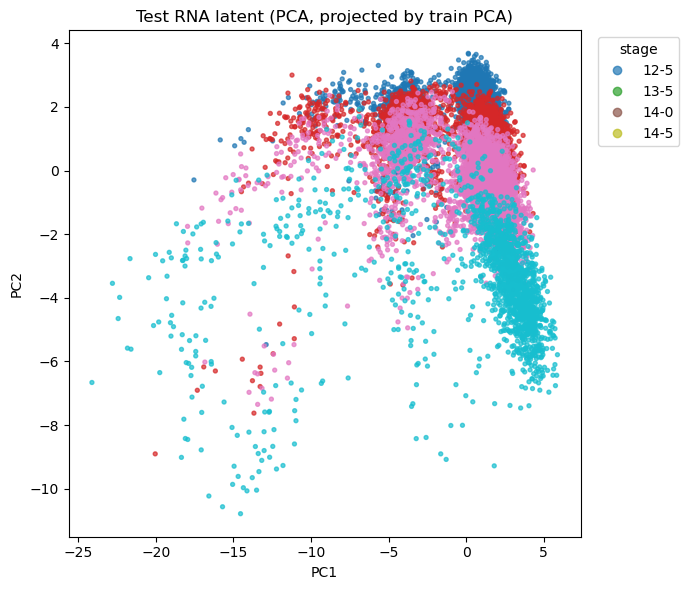

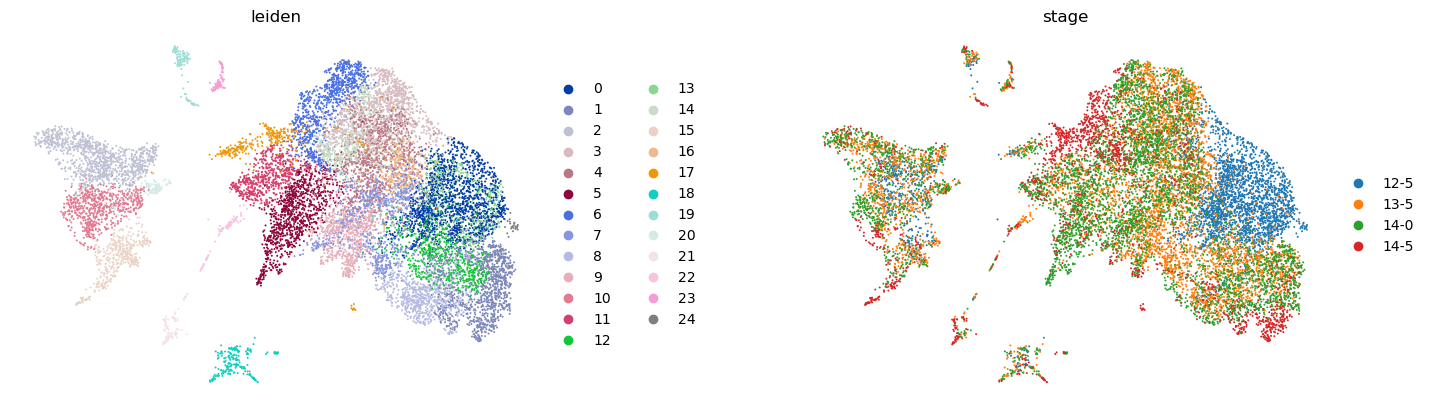

AnnData object with n_obs × n_vars = 14672 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt'
    uns: 'neighbors', 'leiden', 'umap', 'leiden_colors', 'stage_colors'
    obsm: 'X_rna_encoder', 'X_pca_encoder', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [11]:
test_plot_key = test_day_key if test_day_key is not None else test_group_key

plt.figure(figsize=(7, 6))
if test_plot_key is None:
    plt.scatter(test_pca_2d[:, 0], test_pca_2d[:, 1], s=8, alpha=0.7, color="#dd8452")
else:
    labels = test_latent_adata.obs[test_plot_key].astype(str)
    categories = pd.Categorical(labels)
    scatter = plt.scatter(test_pca_2d[:, 0], test_pca_2d[:, 1], c=categories.codes, s=8, alpha=0.7, cmap="tab10")
    handles, _ = scatter.legend_elements(num=min(len(categories.categories), 12))
    plt.legend(handles, list(categories.categories[: len(handles)]), title=test_plot_key, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.title("Test RNA latent (PCA, projected by train PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

test_color_keys = ["leiden"]
if test_day_key is not None:
    test_color_keys.append(test_day_key)
elif test_group_key is not None:
    test_color_keys.append(test_group_key)

sc.pl.umap(test_latent_adata, color=test_color_keys, wspace=0.35, frameon=False)
test_latent_adata

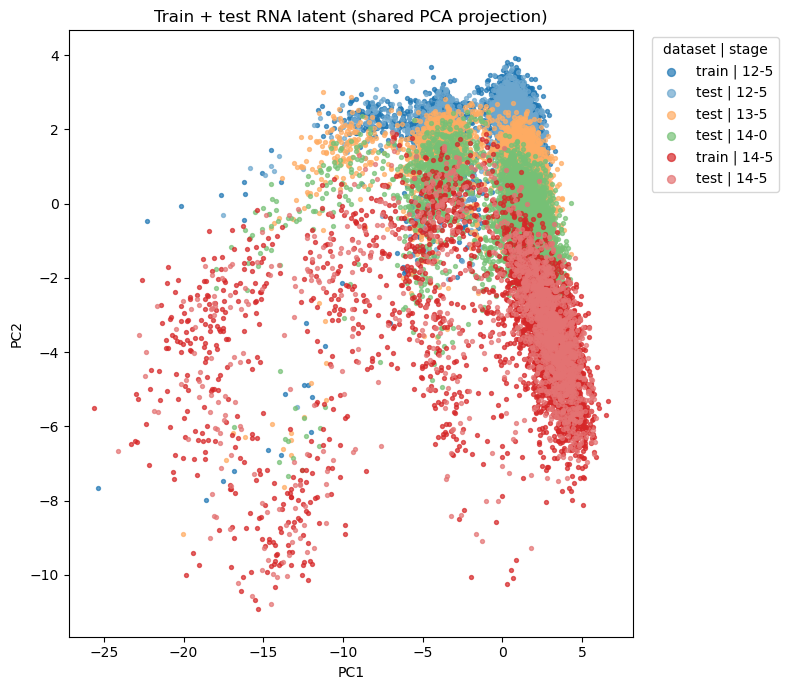

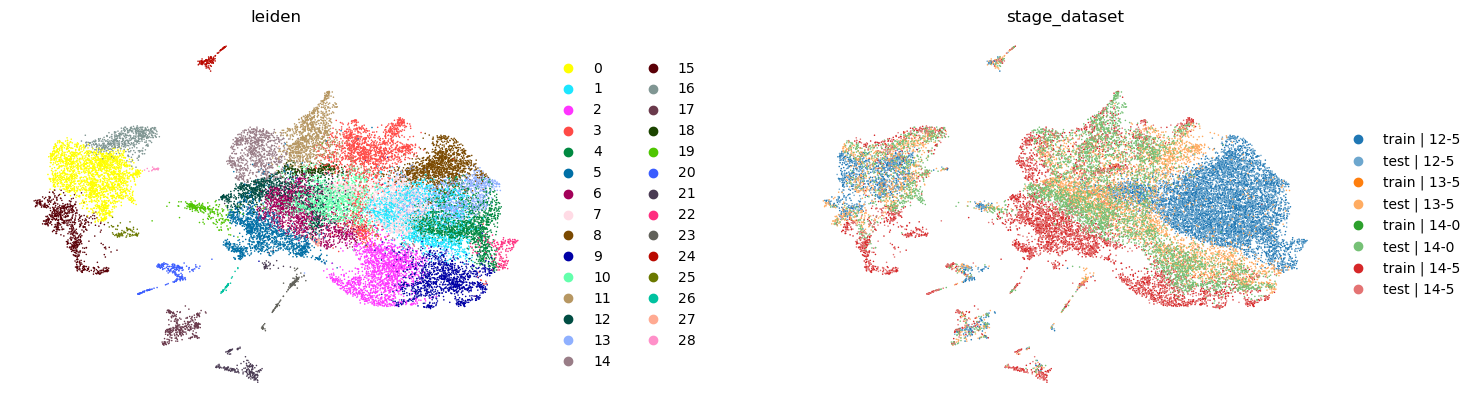

AnnData object with n_obs × n_vars = 24030 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage', 'leiden', 'dataset', 'stage_dataset'
    uns: 'neighbors', 'leiden', 'umap', 'stage_dataset_colors', 'leiden_colors'
    obsm: 'X_rna_encoder', 'X_pca_encoder', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [12]:
combined_stage_key = combined_day_key if combined_day_key is not None else combined_group_key

plt.figure(figsize=(8, 7))
if combined_stage_key is None:
    dataset_colors = {"train": "#4c78a8", "test": "#f58518"}
    for dataset_name, color in dataset_colors.items():
        mask = combined_latent_adata.obs["dataset"].astype(str) == dataset_name
        plt.scatter(
            combined_latent_adata.obsm["X_pca_encoder"][mask, 0],
            combined_latent_adata.obsm["X_pca_encoder"][mask, 1],
            s=8,
            alpha=0.7,
            label=dataset_name,
            color=color,
        )
else:
    for label in combined_latent_adata.obs["stage_dataset"].cat.categories:
        mask = combined_latent_adata.obs["stage_dataset"].astype(str) == label
        if mask.sum() == 0:
            continue
        color_idx = list(combined_latent_adata.obs["stage_dataset"].cat.categories).index(label)
        plt.scatter(
            combined_latent_adata.obsm["X_pca_encoder"][mask, 0],
            combined_latent_adata.obsm["X_pca_encoder"][mask, 1],
            s=8,
            alpha=0.7,
            label=label,
            color=combined_latent_adata.uns["stage_dataset_colors"][color_idx],
        )
    plt.legend(title="dataset | stage", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2)

plt.title("Train + test RNA latent (shared PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

combined_color_keys = ["leiden"]
if "stage_dataset" in combined_latent_adata.obs.columns:
    combined_color_keys.append("stage_dataset")
elif combined_stage_key is not None:
    combined_color_keys.append(combined_stage_key)

sc.pl.umap(combined_latent_adata, color=combined_color_keys, wspace=0.35, frameon=False)
combined_latent_adata